# Retreino acumulativo depois de uma mudança de conceito — o que foi feito e o que aprendemos

**Equipamento:** B-8802B · **Período:** jan/2025 a ago/2026

## Resumo em 5 linhas
1. A pergunta: depois de detectar uma mudança de conceito, dá para pôr um modelo novo em produção com **1 mês**
   de dado, em vez de esperar 12, e ir retreinando todo mês?
2. **Falso positivo: sim.** O modelo provisório alarma pouco desde o 1º mês (0,09 % do tempo em 19 meses).
3. **Sensibilidade a falha: só a partir de ~8 meses.** Com 4 a 7 meses, o modelo pode ficar cego.
4. A falha **real** de 2022 é detectada ~2 dias antes em quase todas as etapas. A falha **sintética** varia muito
   (de "não detecta" a 29 h), conforme o modelo e a data do teste.
5. No caminho, achamos e corrigimos um erro de medição: modelos que **já alarmavam** numa janela sem falha pareciam
   "detectar" a falha sintética.

Este notebook só lê os resultados das tasks do ClearML (não treina nada).

## 1. O contexto

O B-8802B tem um modelo de detecção de anomalia (autoencoder, VAE) que aprende a operação normal e alarma quando
os sensores se afastam dela. Em 2022 o equipamento falhou (trinca no acoplamento) e foi reparado. Depois do reparo
o **normal mudou** (novos regimes de operação) e o modelo de 2022 passou a alarmar 12 % do tempo sem nada errado:
é uma **mudança de conceito**.

O modelo em produção hoje (B-8802B-2025) foi retreinado com **12 meses** de 2025. A dúvida é o que fazer na
**próxima** mudança de conceito: esperar 12 meses de dado novo é muito tempo operando com um modelo desatualizado.

## 2. O experimento

**O esquema testado** (código em `src/transpetro_modelos/drift/acumulativo.py`):

| período | modelo em produção |
|---|---|
| jan/2025 | **quarentena**: a mudança é detectada, o modelo antigo continua e os alarmes dele são tratados com ressalva |
| fev/2025 | modelo provisório treinado com **1 mês** (jan/2025) |
| mar/2025 | retreinado com **2 meses** (jan–fev) |
| … | a cada mês, retreinado com tudo o que acumulou |
| jan/2026 em diante | modelo com **12 meses**, fixo |

Cada etapa usa a mesma receita do modelo de produção: VAE, limiar = média + 6,5 desvios do erro no treino,
alarme quando 15 de 20 leituras seguidas passam do limiar.

**3 candidatos por etapa.** O resultado de um treino depende da inicialização aleatória (a "semente"), e isso
já tinha aparecido antes: o mesmo modelo, treinado duas vezes, pode sair bom ou cego. Por isso cada etapa treinou
3 candidatos e escolheu um, usando **só informação disponível no momento do retreino**: falso positivo na
validação e uma falha sintética injetada no último mês do treino.

**Onde rodou:** no worker do ClearML.
- `retreino-acumulativo-b8802b-3c` (task `2a0ff054…`): treino dos 36 candidatos (12 etapas × 3), ~16 h.
- `sintetica-varias-datas-b8802b` (task `0abc1aed…`): reavaliação dos mesmos 36 modelos em 5 datas, sem treinar.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from transpetro_modelos.drift import acumulativo as ac

R = PROJECT_ROOT / "results/acumulativo_b8802b_3c"          # resultados baixados das tasks do ClearML
etapas = pd.read_csv(R / "etapas.csv", parse_dates=["vivo_ini", "vivo_fim"])
cands = pd.read_csv(R / "candidatos.csv")
datas = pd.read_csv(R / "sintetica_varias_datas.csv")
base = pd.read_csv(R / "alarme_base_por_janela.csv")
print(f"{len(etapas)} etapas · {len(cands)} candidatos · {datas['data'].nunique()} datas de falha sintética")

12 etapas · 36 candidatos · 5 datas de falha sintética


## 3. Resultado 1 — falso positivo

### A série completa: o que o sistema teria alarmado
Emendando, mês a mês, o modelo que estaria em produção em cada momento. Em jan/2025 (quarentena) aparece o modelo
antigo. A curva é o erro de reconstrução dividido pelo limiar do modelo vigente: acima de 1 está acima do limiar.

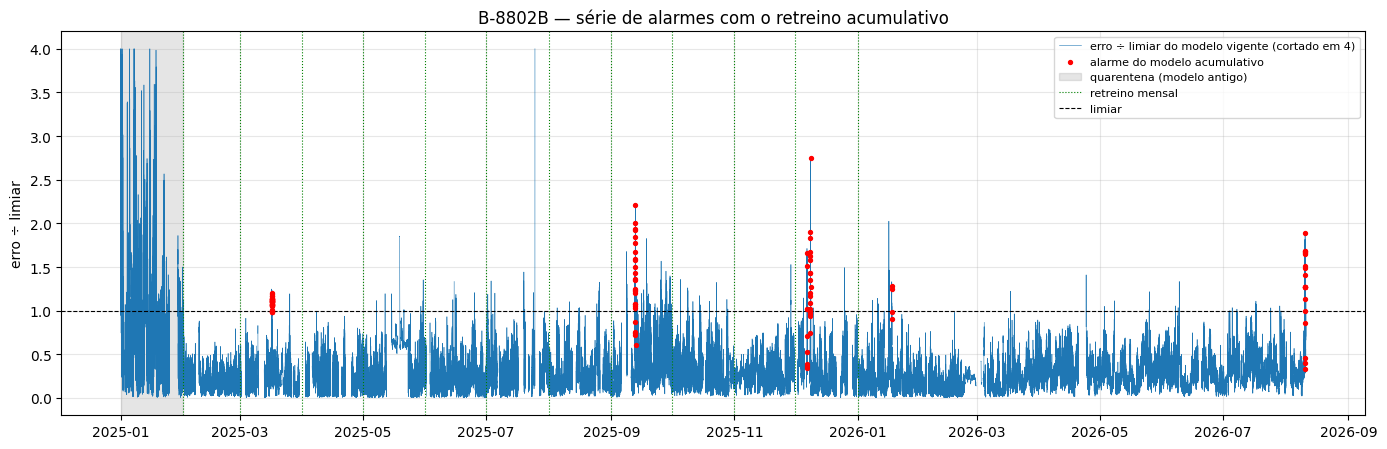

fora da quarentena: 0.086 % do tempo em alarme (o modelo antigo, no mesmo período: 12,2 %)


In [2]:
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"
thr_antigo = json.loads((DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE/alarm.json").read_text())["threshold"]
antigo = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv", index_col=0, parse_dates=True)
quarentena = antigo.loc[:"2025-01-31"].rename(columns={"reconstruction_error": "erro", "is_anomaly": "alarme"})[["erro", "alarme"]]
quarentena["limiar"] = thr_antigo
serie = ac.serie_emendada(R, quarentena)
razao = (serie["erro"] / serie["limiar"]).clip(upper=4)
buraco = serie.index.to_series().diff() > pd.Timedelta(hours=6)
r_plot = pd.concat([razao, pd.Series(np.nan, index=serie.index[buraco] - pd.Timedelta(seconds=1))]).sort_index()
al = serie[serie["alarme"] & (serie["etapa"] > 0)]
plt.figure(figsize=(14, 4.6))
plt.plot(r_plot.index, r_plot.values, linewidth=0.4, label="erro ÷ limiar do modelo vigente (cortado em 4)")
plt.scatter(al.index, (al["erro"] / al["limiar"]).clip(upper=4), s=8, color="red", zorder=3, label="alarme do modelo acumulativo")
plt.axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-02-01"), color="gray", alpha=0.2, label="quarentena (modelo antigo)")
for i, t in enumerate(etapas["vivo_ini"]):
    plt.axvline(t, color="green", linestyle=":", linewidth=0.8, label="retreino mensal" if i == 0 else None)
plt.axhline(1, color="black", linestyle="--", linewidth=0.8, label="limiar")
plt.ylabel("erro ÷ limiar"); plt.title("B-8802B — série de alarmes com o retreino acumulativo")
plt.legend(loc="upper right", fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
fora = serie[serie["etapa"] > 0]
print(f"fora da quarentena: {100 * fora['alarme'].mean():.3f} % do tempo em alarme (o modelo antigo, no mesmo período: 12,2 %)")

### Os episódios de alarme
Cada episódio é um bloco de alarmes separado do seguinte por mais de 12 h. "Sensor principal" é o que mais pesou
no erro de reconstrução. A coluna "já justificado" marca os episódios reais de 2025–26 que têm análise técnica em
`docs/justificativa_alarmes_b8802b_2025.md`.

In [3]:
CONHECIDOS = {"sim — térmico (ep1)": ("2025-12-06 22:45", "2025-12-07 01:20"),
              "sim — vibração LA+LNA (ep2)": ("2026-01-17 21:30", "2026-01-17 22:40"),
              "sim — operacional (ep3)": ("2026-07-24 14:35", "2026-07-24 14:55"),
              "sim — sucção/vibração (ep4)": ("2026-08-10 12:45", "2026-08-10 16:25")}
ep = ac.episodios(serie, R)
def conhecido(r):
    for nome, (a, b) in CONHECIDOS.items():
        if r["inicio"] <= pd.Timestamp(b) + pd.Timedelta(hours=12) and r["fim"] >= pd.Timestamp(a) - pd.Timedelta(hours=12):
            return nome
    return "não → candidato a falso positivo"
ep["já justificado?"] = ep.apply(conhecido, axis=1)
pd.DataFrame({"início": ep["inicio"].dt.strftime("%d/%m/%Y %H:%M"), "duração (h)": ep["duracao_h"],
              "meses de treino do modelo": ep["etapa"], "sensor principal": ep["sensor_principal"],
              "peso do sensor (%)": ep["peso_sensor_principal_pct"], "já justificado?": ep["já justificado?"]})

,início,duração (h),meses de treino do modelo,sensor principal,peso do sensor (%),já justificado?
0,16/03/2025 19:10,3.1,2,Pressão Descarga,53.0,não → candidato a falso positivo
1,12/09/2025 21:25,4.2,8,Vibração Bomba LA,46.0,não → candidato a falso positivo
2,06/12/2025 23:00,2.4,11,Temperatura Bomba LA,34.0,sim — térmico (ep1)
3,08/12/2025 14:30,2.6,11,Pressão Descarga,47.0,não → candidato a falso positivo
4,17/01/2026 21:50,0.3,12,Vibração Bomba LA,30.0,sim — vibração LA+LNA (ep2)
5,10/08/2026 13:00,3.5,12,Temperatura Bomba LA,31.0,sim — sucção/vibração (ep4)


**Leitura:** metade dos episódios são eventos reais já analisados. Os candidatos a falso positivo são poucos,
e dois deles têm a **pressão de descarga** como sensor principal, num nível na borda ou acima do que o modelo
tinha visto no treino. São os casos a olhar se for preciso calibrar melhor.

## 4. Resultado 2 — sensibilidade a falha

Um modelo com pouco alarme só é bom se ainda detectar falha: um modelo que nunca alarma tem 0 % de falso positivo e
é inútil. Medimos a sensibilidade de dois jeitos:
- **falha real de 2022:** a série da falha que aconteceu, que nenhuma etapa viu no treino;
- **falha sintética:** a "assinatura" medida da falha de 2022 (vibração +1,2 a +1,5 mm/s, temperatura do mancal
  +6,7 °C, pressões −3 %) somada aos dados reais como uma rampa de 48 h. A pergunta é quantas horas antes do fim da
  rampa o modelo alarma.

### 4.1 Falha real de 2022

In [4]:
t = etapas[["etapa", "falha_2022_dias", "normal_2022_pct"]].copy()
t.columns = ["meses de treino", "alarme antes da falha (dias)", "alarme no normal de 2022 (%)"]
t.set_index("meses de treino").round(2).T

meses de treino,1,2,3,4,5,6,7,8,9,10,11,12
alarme antes da falha (dias),1.80,0.61,1.94,2.00,NaN,1.83,2.1,2.12,2.12,2.12,2.12,2.12
alarme no normal de 2022 (%),1.04,0.03,0.20,1.64,0.0,0.08,0.0,3.25,3.18,1.57,0.00,0.00


**Leitura:** a falha real é detectada com ~2 dias de antecedência em quase todas as etapas, até com 1 mês de
treino (as exceções são 2 meses, com 0,6 dia, e 5 meses, que não detecta). Mas repare na 2ª linha: com 8 a 10 meses
o modelo alarma 1,6 % a 3,2 % do tempo no **normal** de 2022. Nessas etapas a detecção vale menos, porque o modelo
já alarmava bastante antes da falha. Os casos mais limpos são 1 a 7 e 11–12 meses (alarme no normal de 2022 ≤ 1,6 %).

### 4.2 Falha sintética em várias datas, e o erro de medição que encontramos

Primeiro injetamos a falha numa data só (10/06/2026) e metade das etapas pareceu cega. Para saber se o problema era
do modelo ou da data, reavaliamos os 36 modelos com a falha em 5 datas de 2026 (nenhuma etapa treinou com 2026).

Aí apareceu algo estranho: em 15/07/2026 quase todos "detectavam" a falha 47 h antes, praticamente no início da
rampa, quando a falha injetada ainda é quase nula. Checamos os mesmos modelos **sem** falha injetada:

In [5]:
b = base.groupby("data")["alarma_sem_falha"].agg(["sum", "size"]).rename(columns={"sum": "já alarmam sem falha", "size": "candidatos"})
b

,já alarmam sem falha,candidatos
data,,
2026-01-20,0,36
2026-02-10,0,36
2026-03-10,0,36
2026-06-10,0,36
2026-07-15,18,36


Em 15/07, **18 dos 36 modelos já alarmavam sem nenhuma falha**: são os das etapas 1 a 6, treinados só com os
primeiros meses de 2025, que estranham o ponto de operação de julho/2026. Aquilo era alarme falso, não detecção.
Essas janelas foram descartadas, e o código foi corrigido para descartá-las automaticamente
(`drift/battery.py` e `drift/acumulativo.py`).

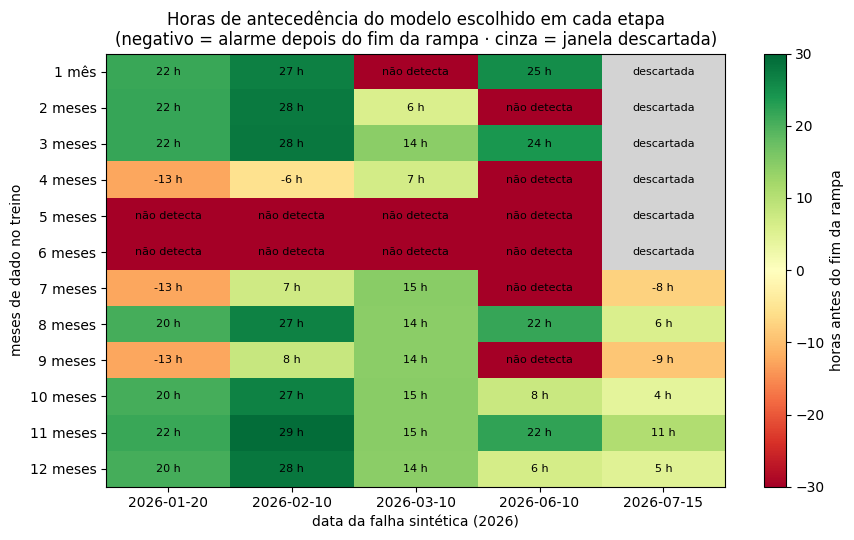

In [6]:
v = datas.merge(base, on=["etapa", "semente", "data"])
v = v[~v["alarma_sem_falha"]]
esc = v[v["escolhido"] == True].pivot_table(index="etapa", columns="data", values="sintetica_100_h").reindex(range(1, 13))
cols = sorted(datas["data"].unique())
esc = esc.reindex(columns=cols)
sem_escolhida = {int(r.etapa): int(r.semente) for r in cands[cands["escolhido"]].itertuples()}
contam = np.array([[bool(base[(base["etapa"] == k) & (base["data"] == d) & (base["semente"] == sem_escolhida[k])]["alarma_sem_falha"].any())
                    for d in cols] for k in range(1, 13)])
M = np.ma.masked_array(esc.fillna(-30).clip(-30, 30).values, mask=contam)
cmap = plt.get_cmap("RdYlGn").copy(); cmap.set_bad("lightgray")
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(M, cmap=cmap, vmin=-30, vmax=30, aspect="auto")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = esc.values[i, j]
        txt = "descartada" if contam[i, j] else ("não detecta" if np.isnan(val) else f"{val:.0f} h")
        ax.text(j, i, txt, ha="center", va="center", fontsize=8)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
ax.set_yticks(range(12)); ax.set_yticklabels([f"{k} mês" if k == 1 else f"{k} meses" for k in range(1, 13)])
ax.set_xlabel("data da falha sintética (2026)"); ax.set_ylabel("meses de dado no treino")
ax.set_title("Horas de antecedência do modelo escolhido em cada etapa\n(negativo = alarme depois do fim da rampa · cinza = janela descartada)")
plt.colorbar(im, label="horas antes do fim da rampa"); plt.tight_layout(); plt.show()

**Leitura:**
- **Com 8, 10, 11 e 12 meses** o modelo detecta a falha em todas as datas válidas, com 4 a 29 h de antecedência.
- **Com 1 a 3 meses** detecta bem em jan–fev/2026 e pior nas outras datas.
- **Com 5 e 6 meses** não detecta em nenhuma data; com 4, 7 e 9, fraco.
- A antecedência **não é um número fixo**: mesmo nos bons modelos, varia de 4 a 29 h conforme a data.

Testamos uma explicação (a temperatura do mancal, ~8 °C mais baixa em 2026, esconderia a falha) e ela **não se
confirmou**: datas igualmente frias deram resultados diferentes. A causa da cegueira de algumas etapas ficou em aberto.

## 5. E os alarmes que sobram no modelo de 12 meses? O que fazer com eles

O modelo em produção hoje (B-8802B-2025, treinado com os 12 meses de 2025) operou em 2026 sem ter visto esse ano.
Não houve falha em 2026, então todo alarme ali é, a princípio, suspeito. Olhamos cada episódio: quanto durou,
qual sensor puxou o erro e se algum sensor saiu da faixa em que o modelo foi treinado.

In [7]:
DEPL = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEPL)); import simpred_inference as si
import torch
from transpetro_modelos.drift import battery
BP = DEPL / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"; MP = si.carregar_modelo(BP)
raw = si.carregar_dados(DEPL / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv")
raw22 = si.carregar_dados(next((DEPL / "B-8802B/dados").rglob("*_raw.csv")))
prever = lambda df: si.prever(BP, MP, si.preprocessar(BP, df))
Xp = si.preprocessar(BP, raw); resp = si.prever(BP, MP, Xp)
with torch.no_grad():
    rec = MP(torch.tensor(Xp.values, dtype=torch.float32))[0].numpy()
por_sensor = pd.DataFrame((rec - Xp.values) ** 2, index=Xp.index, columns=Xp.columns)
thr_p = json.loads((BP / "alarm.json").read_text())["threshold"]
faixa = json.loads((BP / "clip_bounds.json").read_text())
a26 = resp[resp["is_anomaly"] & (resp.index >= "2026-01-01")]
grupos = (a26.index.to_series().diff() > pd.Timedelta(hours=12)).cumsum()
linhas = []
for _, e in a26.groupby(grupos):
    c = por_sensor.loc[e.index].mean(); w = raw.loc[e.index.min(): e.index.max()]; w = w[w["Pressão Descarga"] > 35]
    fora = [col for col, (lo, hi) in faixa.items() if col in w and ((w[col] < lo) | (w[col] > hi)).mean() > 0.5]
    linhas.append({"início": f"{e.index.min():%d/%m/%Y %H:%M}", "duração (h)": round((e.index.max() - e.index.min()).total_seconds() / 3600 + 5 / 60, 1),
                   "pico (× limiar)": round(float((e["reconstruction_error"] / thr_p).max()), 2), "sensor principal": c.idxmax(),
                   "sensor fora da faixa de treino": ", ".join(fora) or "nenhum"})
print(f"modelo de produção em 2026: {100 * resp.loc['2026', 'is_anomaly'].mean():.3f} % do tempo em alarme")
pd.DataFrame(linhas)

modelo de produção em 2026: 0.076 % do tempo em alarme


,início,duração (h),pico (× limiar),sensor principal,sensor fora da faixa de treino
0,17/01/2026 21:30,1.2,1.58,Vibração Bomba LNA,Vibração Bomba LA
1,24/07/2026 14:35,0.4,1.08,Vibração Bomba LA,nenhum
2,10/08/2026 12:45,3.8,1.66,Temperatura Bomba LA,Temperatura Bomba LA


**Leitura:**
- **17/01 e 10/08** têm um sensor **fora da faixa normal** (vibração LA; temperatura LA). São desvios físicos reais
  nos sensores, com análise técnica em `docs/justificativa_alarmes_b8802b_2025.md`. O certo é mantê-los: o papel do
  modelo é avisar a operação, que verifica a causa.
- **24/07** é o típico falso positivo: durou 24 min, passou do limiar por pouco (1,08×) e nenhum sensor saiu da faixa.

**O que dá para fazer:** exigir que um episódio dure pelo menos **1 hora** para virar alarme. Desvios reais de falha
duram horas ou dias; oscilações de operação, minutos. O custo é o alarme sair 1 h mais tarde. Testamos a regra contra
tudo o que mede sensibilidade:

In [8]:
def min_duracao(al, horas):
    out = pd.Series(False, index=al.index); a = al[al]
    if a.empty: return out
    g = (a.index.to_series().diff() > pd.Timedelta(hours=12)).cumsum()
    for _, e in a.groupby(g):
        if (e.index.max() - e.index.min()) >= pd.Timedelta(hours=horas):
            out[e.index[e.index >= e.index.min() + pd.Timedelta(hours=horas)]] = True
    return out
n_ep = lambda al: 0 if not al.any() else int((al[al].index.to_series().diff() > pd.Timedelta(hours=12)).sum() + 1)
FALHA = pd.Timestamp("2022-07-06 10:00"); r22 = prever(raw22)["is_anomaly"]
sy = battery.BATTERY["B-8802B-2025"]["synthetic"]; DATAS = ["2026-01-20", "2026-02-10", "2026-03-10", "2026-06-10", "2026-07-15"]
inj = {d: prever(battery.inject(raw.loc[pd.Timestamp(d) - pd.Timedelta(days=3): pd.Timestamp(d) + pd.Timedelta(hours=84)],
                                sy["signature"], pd.Timestamp(d), sy["ramp_h"], sy["hold_h"], 1.0))["is_anomaly"] for d in DATAS}
linhas = []
for nome, h in [("regra atual", 0), ("episódio ≥ 1 h", 1.0)]:
    f = resp["is_anomaly"] if h == 0 else min_duracao(resp["is_anomaly"], h)
    f22 = r22 if h == 0 else min_duracao(r22, h)
    rampa = f22[(f22.index >= "2022-06-29") & (f22.index < FALHA)]
    linha = {"regra": nome, "alarme em 2026 (%)": round(100 * f.loc["2026"].mean(), 3), "episódios em 2026": n_ep(f.loc["2026"]),
             "falha real 2022 (dias antes)": round((FALHA - rampa[rampa].index.min()).total_seconds() / 86400, 2)}
    for d in DATAS:
        t0 = pd.Timestamp(d); tf = t0 + pd.Timedelta(hours=sy["ramp_h"]); w = inj[d] if h == 0 else min_duracao(inj[d], h)
        w = w[(w.index >= t0) & (w.index <= tf + pd.Timedelta(hours=sy["hold_h"]))]
        linha[f"sintética {d[5:]} (h)"] = None if not w.any() else round((tf - w[w].index.min()).total_seconds() / 3600, 1)
    linhas.append(linha)
pd.DataFrame(linhas).set_index("regra").T

regra,regra atual,episódio ≥ 1 h
alarme em 2026 (%),0.076,0.025
episódios em 2026,3.000,2.000
falha real 2022 (dias antes),2.120,2.080
sintética 01-20 (h),21.500,20.500
sintética 02-10 (h),29.000,28.000
sintética 03-10 (h),14.800,13.800
sintética 06-10 (h),22.200,21.200
sintética 07-15 (h),8.200,7.200


**Leitura:** com a regra de 1 hora, 2026 fica com **2 episódios, os dois com sensor fora da faixa normal, e
nenhum alarme sem desvio físico**. A falha real de 2022 continua 2,1 dias antes, e a falha sintética continua sendo
detectada nas 5 datas (1 h mais tarde). **Recomendação:** adotar a regra de 1 hora no modelo de produção. É uma mudança
no pós-processamento do alarme, sem retreinar.

Os candidatos a falso positivo dos modelos **provisórios** (16/03/2025, 12/09/2025, 08/12/2025) são outra conversa:
vêm de modelos com poucos meses, na borda da faixa que viram. A mesma regra de 1 hora e mais meses de dado
resolvem parte deles; o restante é mais um motivo para não depender do modelo provisório para proteção.

## 6. O que isso significa

1. **O retreino acumulativo resolve o falso positivo cedo.** Com 1 mês de dado o modelo novo já alarma muito menos
   que o modelo desatualizado.
2. **A proteção contra falha só é confiável a partir de ~8 meses de dado.** Antes disso o modelo provisório deve
   ser tratado como cobertura parcial, com o monitor atento em paralelo.
3. **Modelos provisórios envelhecem rápido.** Um modelo de poucos meses, usado meses depois, começa a alarmar sozinho.
   No esquema acumulativo eles precisam mesmo ser trocados todo mês.
4. **A falha real de 2022 é o resultado mais confiável** (~2 dias em quase todas as etapas). A antecedência da falha
   sintética deve ser apresentada como faixa (4 a 29 h), não como um número.

## 7. Limitações e próximos passos
- **Uma só falha real.** A falha sintética usa a assinatura dessa mesma falha.
- **3 candidatos por etapa** não bastaram para achar um modelo sensível nas etapas 4 a 7. Mais sementes podem ajudar;
  vale testar antes de concluir que essas etapas são cegas por natureza.
- **A escolha do candidato** usou uma falha sintética só (no último mês do treino), e ela não previu bem a
  sensibilidade nas outras datas. Escolher pela média de várias datas é o próximo teste.
- **Os candidatos a falso positivo** (pressão de descarga na borda da faixa de treino) precisam ser verificados com a
  operação antes de qualquer calibração.

## Glossário
- **Mudança de conceito:** o "normal" do equipamento muda (reparo, novo regime) e o modelo fica desatualizado.
- **Falso positivo:** alarme sem problema real no equipamento.
- **Etapa:** um mês do esquema acumulativo; a etapa k usa um modelo treinado com k meses.
- **Candidato / semente:** o mesmo modelo treinado várias vezes com inicializações diferentes.
- **Falha sintética:** a assinatura da falha de 2022 somada aos dados reais, para testar se o modelo detectaria.
- **Janela contaminada:** período em que o modelo já alarma sem falha; ali a falha sintética não mede detecção.